<a href="https://colab.research.google.com/github/haeshal25/myreposit/blob/main/Final_Music_Generes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip generes

Archive:  generes.zip
   creating: generes/
   creating: generes/blues/
  inflating: generes/blues/blues.00000.au  
  inflating: generes/blues/blues.00001.au  
  inflating: generes/blues/blues.00002.au  
  inflating: generes/blues/blues.00003.au  
  inflating: generes/blues/blues.00004.au  
  inflating: generes/blues/blues.00005.au  
  inflating: generes/blues/blues.00006.au  
  inflating: generes/blues/blues.00007.au  
  inflating: generes/blues/blues.00008.au  
  inflating: generes/blues/blues.00009.au  
  inflating: generes/blues/blues.00010.au  
  inflating: generes/blues/blues.00011.au  
  inflating: generes/blues/blues.00012.au  
  inflating: generes/blues/blues.00013.au  
  inflating: generes/blues/blues.00014.au  
  inflating: generes/blues/blues.00015.au  
  inflating: generes/blues/blues.00016.au  
  inflating: generes/blues/blues.00017.au  
  inflating: generes/blues/blues.00018.au  
  inflating: generes/blues/blues.00019.au  
  inflating: generes/blues/blues.00020.au  
  in

In [ ]:
import os
import pickle
from glob import iglob
import numpy as np
import librosa

DATA_AUDIO_DIR = '/content/genres'
TARGET_SR = 8000
OUTPUT_DIR = './output'
OUTPUT_DIR_TRAIN = os.path.join(OUTPUT_DIR, 'train')
OUTPUT_DIR_TEST = os.path.join(OUTPUT_DIR, 'test')
AUDIO_LENGTH = 60000

In [ ]:
os.makedirs('/content/output/train/')
os.makedirs('/content/output/test/')

In [ ]:
class_ids = {
    'blues': 0,
    'classical': 1,
    'country': 2,
    'disco': 3,
    'hiphop': 4,
    'jazz': 5,
    'metal': 6,
    'pop': 7,
    'reggae': 8,
    'rock': 9,
}


def extract_class_id(au_filename):

    classes=['blues','classical','country','disco','hiphop','jazz','metal','pop','reggae','rock']

    for cls in classes:
        if cls in au_filename:
            return class_ids.get(cls)

    return class_ids.get('unlabelled')

In [ ]:
def convert_data():
    for i, wav_filename in enumerate(iglob(os.path.join('/content/generes', '**/**.au'), recursive=True)):
        class_id = extract_class_id(wav_filename)
        audio_buf = read_audio_from_filename(wav_filename, target_sr=TARGET_SR)
        # normalize mean 0, variance 1
        audio_buf = (audio_buf - np.mean(audio_buf)) / np.std(audio_buf)
        original_length = len(audio_buf)
        print(i, wav_filename, original_length, np.round(np.mean(audio_buf), 4), np.std(audio_buf))
        if original_length < AUDIO_LENGTH:
            audio_buf = np.concatenate((audio_buf, np.zeros(shape=(AUDIO_LENGTH - original_length, 1))))
            print('PAD New length =', len(audio_buf))
        elif original_length > AUDIO_LENGTH:
            audio_buf = audio_buf[0:AUDIO_LENGTH]
            print('CUT New length =', len(audio_buf))

        output_folder = OUTPUT_DIR_TRAIN
        if i // 10 == 0:
            output_folder = OUTPUT_DIR_TEST

        output_filename = os.path.join(output_folder, str(i) + '.pkl')

        out = {'class_id': class_id,
               'audio': audio_buf,
               'sr': TARGET_SR}
        w=open(output_filename,'wb')
        pickle.dump(out,w)
        w.close()

In [ ]:
def read_audio_from_filename(filename, target_sr):
    audio, _ = librosa.load(filename, sr=target_sr, mono=True)
    audio = audio.reshape(-1, 1)
    return audio

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Lambda,Conv1D, MaxPooling1D,Activation, Dense,BatchNormalization

from tensorflow.keras.models import Sequential
import numpy as np
import pickle
import os
from glob import glob

In [ ]:
OUTPUT_DIR = './output'
OUTPUT_DIR_TRAIN = os.path.join(OUTPUT_DIR, 'train')
OUTPUT_DIR_TEST = os.path.join(OUTPUT_DIR, 'test')

In [ ]:
def get_data(file_list):
    def load_into(_filename, _x, _y):
        with open(_filename, 'rb') as f:
            audio_element = pickle.load(f)
            _x.append(audio_element['audio'])
            _y.append(int(audio_element['class_id']))

    x, y = [], []
    for filename in file_list:
        load_into(filename, x, y)
    return np.array(x), np.array(y)

In [ ]:
def m5(num_classes=10):
    print('Using Model M5')
    m = Sequential()
    m.add(Conv1D(128,
                 input_shape=[AUDIO_LENGTH, 1],
                 kernel_size=80,
                 strides=4,
                 padding='same',
                 kernel_initializer='glorot_uniform',
                 kernel_regularizer=regularizers.l2(0.0001))) # Changed l=0.0001 to 0.0001
    m.add(BatchNormalization())
    m.add(Activation('relu'))
    m.add(MaxPooling1D(pool_size=4, strides=None))
    m.add(Lambda(lambda x: K.mean(x, axis=1))) # Now K is defined


    m.add(Conv1D(128,
                 kernel_size=3,
                 strides=1,
                 padding='same',
                 kernel_initializer='glorot_uniform',
                 kernel_regularizer=regularizers.l2(0.0001))) # Changed l=0.0001 to 0.0001
    m.add(BatchNormalization())
    m.add(Activation('relu'))
    m.add(MaxPooling1D(pool_size=4, strides=None))

    m.add(Conv1D(256,
                 kernel_size=3,
                 strides=1,
                 padding='same',
                 kernel_initializer='glorot_uniform',
                 kernel_regularizer=regularizers.l2(0.0001))) # Changed l=0.0001 to 0.0001
    m.add(BatchNormalization())
    m.add(Activation('relu'))
    m.add(MaxPooling1D(pool_size=4, strides=None))

    m.add(Conv1D(512,
                 kernel_size=3,
                 strides=1,
                 padding='same',
                 kernel_initializer='glorot_uniform',
                 kernel_regularizer=regularizers.l2(0.0001))) # Changed l=0.0001 to 0.0001
    m.add(BatchNormalization())
    m.add(Activation('relu'))
    m.add(MaxPooling1D(pool_size=4, strides=None))

    m.add(Lambda(lambda x: K.mean(x, axis=1)))

     # Same as global average pooling for 1D Conv Layer

    m.add(Dense(num_classes, activation='softmax'))
    return m

In [ ]:
def get_data(file_list):
    def load_into(_filename, _x, _y):
        with open(_filename, 'rb') as f:
            audio_element = pickle.load(f)
            _x.append(audio_element['audio'])
            _y.append(int(audio_element['class_id']))

    x, y = [], []
    for filename in file_list:
        load_into(filename, x, y)
    return np.array(x), np.array(y)

In [ ]:
num_classes = 10
model = m5(num_classes=num_classes)


model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
print(model.summary())

train_files = glob(os.path.join(OUTPUT_DIR_TRAIN, '**.pkl'))
x_tr, y_tr = get_data(train_files)
y_tr = to_categorical(y_tr, num_classes=num_classes)

test_files = glob(os.path.join(OUTPUT_DIR_TEST, '**.pkl'))
x_te, y_te = get_data(test_files)
y_te = to_categorical(y_te, num_classes=num_classes)

print('x_tr.shape =', x_tr.shape)
print('y_tr.shape =', y_tr.shape)
print('x_te.shape =', x_te.shape)
print('y_te.shape =', y_te.shape)



Using Model M5


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)                    │ (None, 15000, 128)          │          10,368 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 15000, 128)          │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 15000, 128)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_4 (MaxPooling1D)       │ (None, 3750, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda_2 (Lambda)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_5 (Conv1D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_5 (Activation)            │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_5 (MaxPooling1D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_6 (Conv1D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_6 (Activation)            │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_6 (MaxPooling1D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_7 (Conv1D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_7 (Activation)            │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_7 (MaxPooling1D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda_3 (Lambda)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴──────────────

 Total params: 10,880 (42.50 KB)

 Trainable params: 10,624 (41.50 KB)

 Non-trainable params: 256 (1.00 KB)

None
x_tr.shape = (0,)
y_tr.shape = (0, 10)
x_te.shape = (0,)
y_te.shape = (0, 10)


In [ ]:
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K
import librosa
import librosa.display
import pylab
import matplotlib.pyplot as plt
from matplotlib import figure
import gc


In [ ]:
import os
os.mkdir('train')
os.mkdir('test')

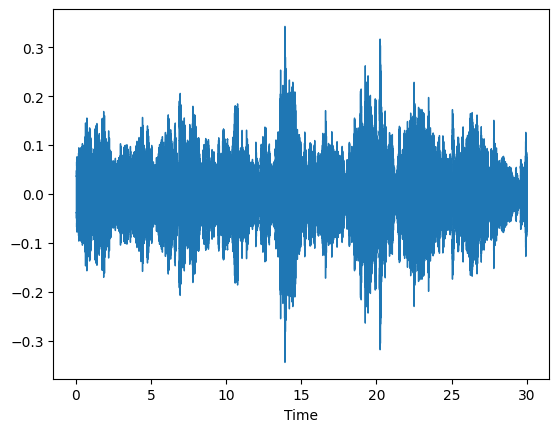

In [ ]:
filename = '/content/generes/classical/classical.00000.au'
y, sr = librosa.load(filename)
# trim silent edges
sample_sound, _ = librosa.effects.trim(y)
librosa.display.waveshow(sample_sound, sr=sr)

In [ ]:
def create_spectrogram(filename,name):
    plt.interactive(False)
    clip, sample_rate = librosa.load(filename, sr=None)
    fig = plt.figure(figsize=[0.72,0.72])
    ax = fig.add_subplot(111)
    ax.axes.get_xaxis().set_visible(False)
    ax.axes.get_yaxis().set_visible(False)
    ax.set_frame_on(False)
    S = librosa.feature.melspectrogram(y=clip, sr=sample_rate)
    librosa.display.specshow(librosa.power_to_db(S, ref=np.max))
    filename  = '/content/train/' + name + '.jpg'
    plt.savefig(filename, dpi=400, bbox_inches='tight',pad_inches=0)
    plt.close()
    fig.clf()
    plt.close(fig)
    plt.close('all')
    del filename,name,clip,sample_rate,fig,ax,S

In [ ]:
!unzip test11.zip
file_list=list(glob("./test11/*"))

Archive:  test11.zip
   creating: test11/
  inflating: test11/blues.00005.au   
  inflating: test11/blues.00006.au   
  inflating: test11/blues.00007.au   
  inflating: test11/blues.00008.au   
  inflating: test11/blues.00009.au   
  inflating: test11/blues.00010.au   
  inflating: test11/blues.00011.au   
  inflating: test11/blues.00012.au   
  inflating: test11/country.00008.au  
  inflating: test11/country.00009.au  
  inflating: test11/country.00010.au  
  inflating: test11/country.00011.au  
  inflating: test11/country.00012.au  
  inflating: test11/country.00013.au  
  inflating: test11/country.00014.au  
  inflating: test11/country.00015.au  
  inflating: test11/country.00016.au  
  inflating: test11/country.00017.au  
  inflating: test11/country.00018.au  
  inflating: test11/metal.00010.au   
  inflating: test11/metal.00011.au   
  inflating: test11/metal.00012.au   
  inflating: test11/metal.00013.au   
  inflating: test11/metal.00014.au   
  inflating: test11/metal.00015.au 

In [ ]:
for i,file in enumerate(file_list):
    if i%10==0 : print(len(file_list)-i)
    filename,name = file,file.split('/')[-1].split('.')[0]
    create_spectrogram(filename,name)

49
39
29
19
9


In [ ]:
To extract MFCC spectral from test11/

SyntaxError: invalid syntax (<ipython-input-27-ee20a4ada519>, line 1)

In [ ]:
import librosa
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D

In [ ]:
# Load audio file and extract MFCC coefficients
audio, sr = librosa.load(filename)
mfccs = librosa.feature.mfcc(y=audio, sr=sr)

In [ ]:
# Define neural network architecture
#model = Sequential()
#model.add(Conv2D(32, (3, 3), activation='relu', input_shape=mfccs.shape))
#model.add(MaxPooling2D((2, 2)))
#model.add(Flatten())
#model.add(Dense(128, activation='relu'))
#model.add(Dropout(0.2))
#model.add(Dense(10, activation='softmax'))
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Assuming mfccs is already defined and has the correct shape
# Replace this with your actual mfccs data. Example:
mfccs = tf.random.normal((10, 20, 40, 1)) # Example shape

model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=mfccs.shape[1:]))  # Corrected input shape
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 18, 38, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 9, 19, 32)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 5472)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         700,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 702,154 (2.68 MB)

 Trainable params: 702,154 (2.68 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
model.fit(mfccs, labels, epochs=10, batch_size=32, validation_data=(val_mfccs, val_labels))